In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from minimos_cuadrados import minimos_cuadrados
from minimos_cuadrado_vid import minimos_cuadrados_vid
from spline_cubico_natural_vid import spline_cubico_natural_vid

In [2]:
# Cargar el dataframe con las variables que se van a utilizar
df = pd.read_csv(r"asthma_disease_data.csv")
pd.set_option('display.max_rows', None)
cols = [
    "Age", "Gender", "PollutionExposure", "PollenExposure", "DustExposure",
    "FamilyHistoryAsthma", "Smoking", "PhysicalActivity",
    "DietQuality", "HistoryOfAllergies" , "Diagnosis"
]
# Vuelve a cargar el dataframe con las variables seleccionadas
df = pd.read_csv("asthma_disease_data.csv", usecols=cols)
# Elimina las filas con valores nulos
df = df.dropna()
print(df)

      Age  Gender  Smoking  PhysicalActivity  DietQuality  PollutionExposure  \
0      63       0        0          0.894448     5.488696           7.388481   
1      26       1        0          5.897329     6.341014           1.969838   
2      57       0        0          6.739367     9.196237           1.460593   
3      40       1        0          1.404503     5.826532           0.581905   
4      61       0        0          4.604493     3.127048           0.980875   
5      21       0        0          0.470044     1.759118           1.711446   
6      45       1        1          9.371784     7.030507           7.664306   
7      26       0        1          8.344096     1.626484           6.939046   
8      49       1        0          2.690256     3.920034           3.180421   
9      45       1        0          2.895720     2.607700           1.711722   
10     27       0        0          3.900003     1.748193           1.546419   
11     62       1        0          6.63

In [3]:
# Muestra las dimensiones del dataframe
df.shape

(2392, 11)

In [4]:
# Muestra la información detallada del dataframe para verificar los tipos de datos y si existen valores nulos.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  2392 non-null   int64  
 1   Gender               2392 non-null   int64  
 2   Smoking              2392 non-null   int64  
 3   PhysicalActivity     2392 non-null   float64
 4   DietQuality          2392 non-null   float64
 5   PollutionExposure    2392 non-null   float64
 6   PollenExposure       2392 non-null   float64
 7   DustExposure         2392 non-null   float64
 8   FamilyHistoryAsthma  2392 non-null   int64  
 9   HistoryOfAllergies   2392 non-null   int64  
 10  Diagnosis            2392 non-null   int64  
dtypes: float64(5), int64(6)
memory usage: 205.7 KB


<Figure size 1000x600 with 0 Axes>

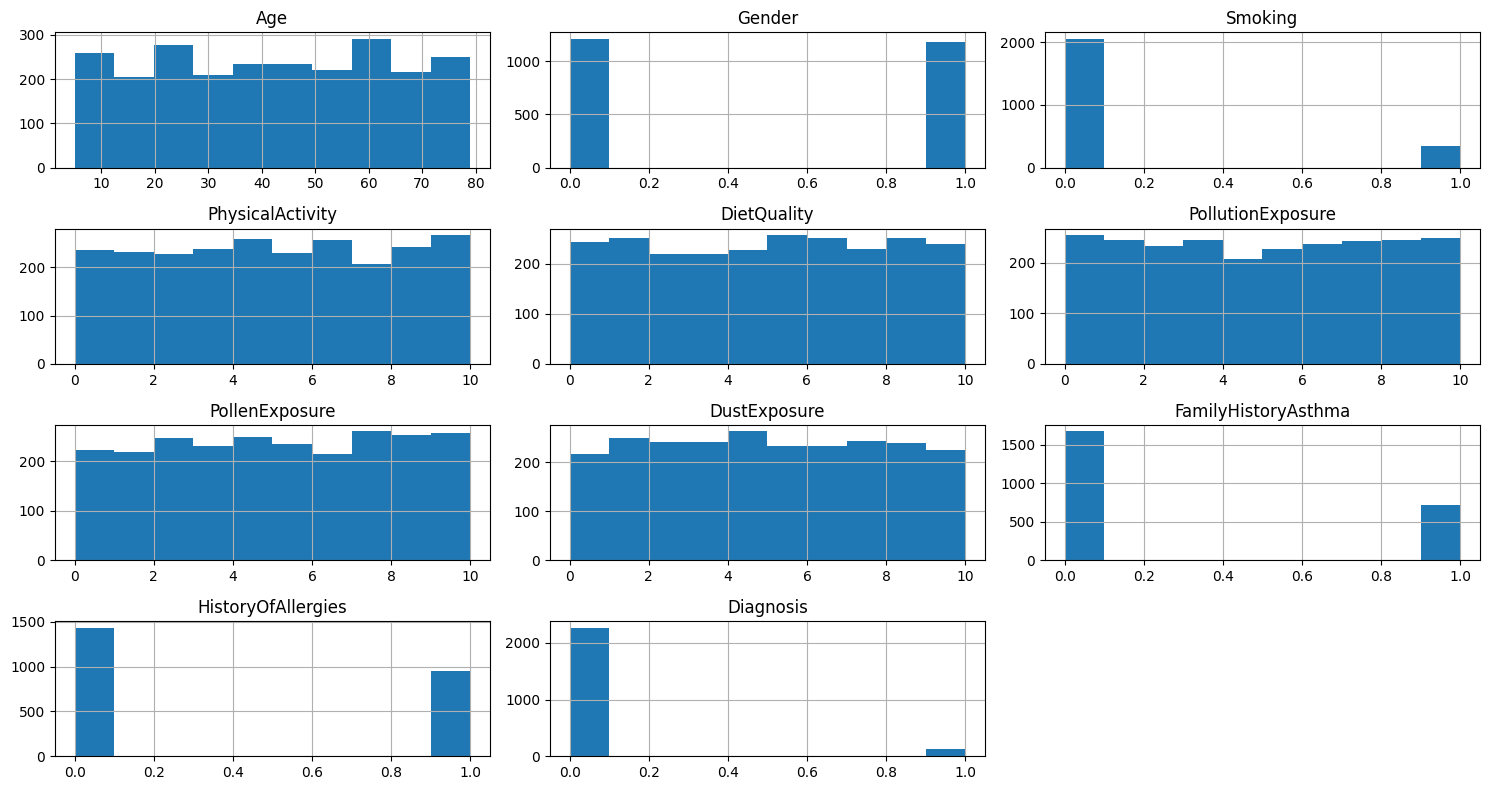

In [5]:
# Visualización de la distribución de los datos
plt.figure(figsize=(10, 6))
df.describe()
df.hist(figsize=(15, 8))
plt.tight_layout()
plt.show()

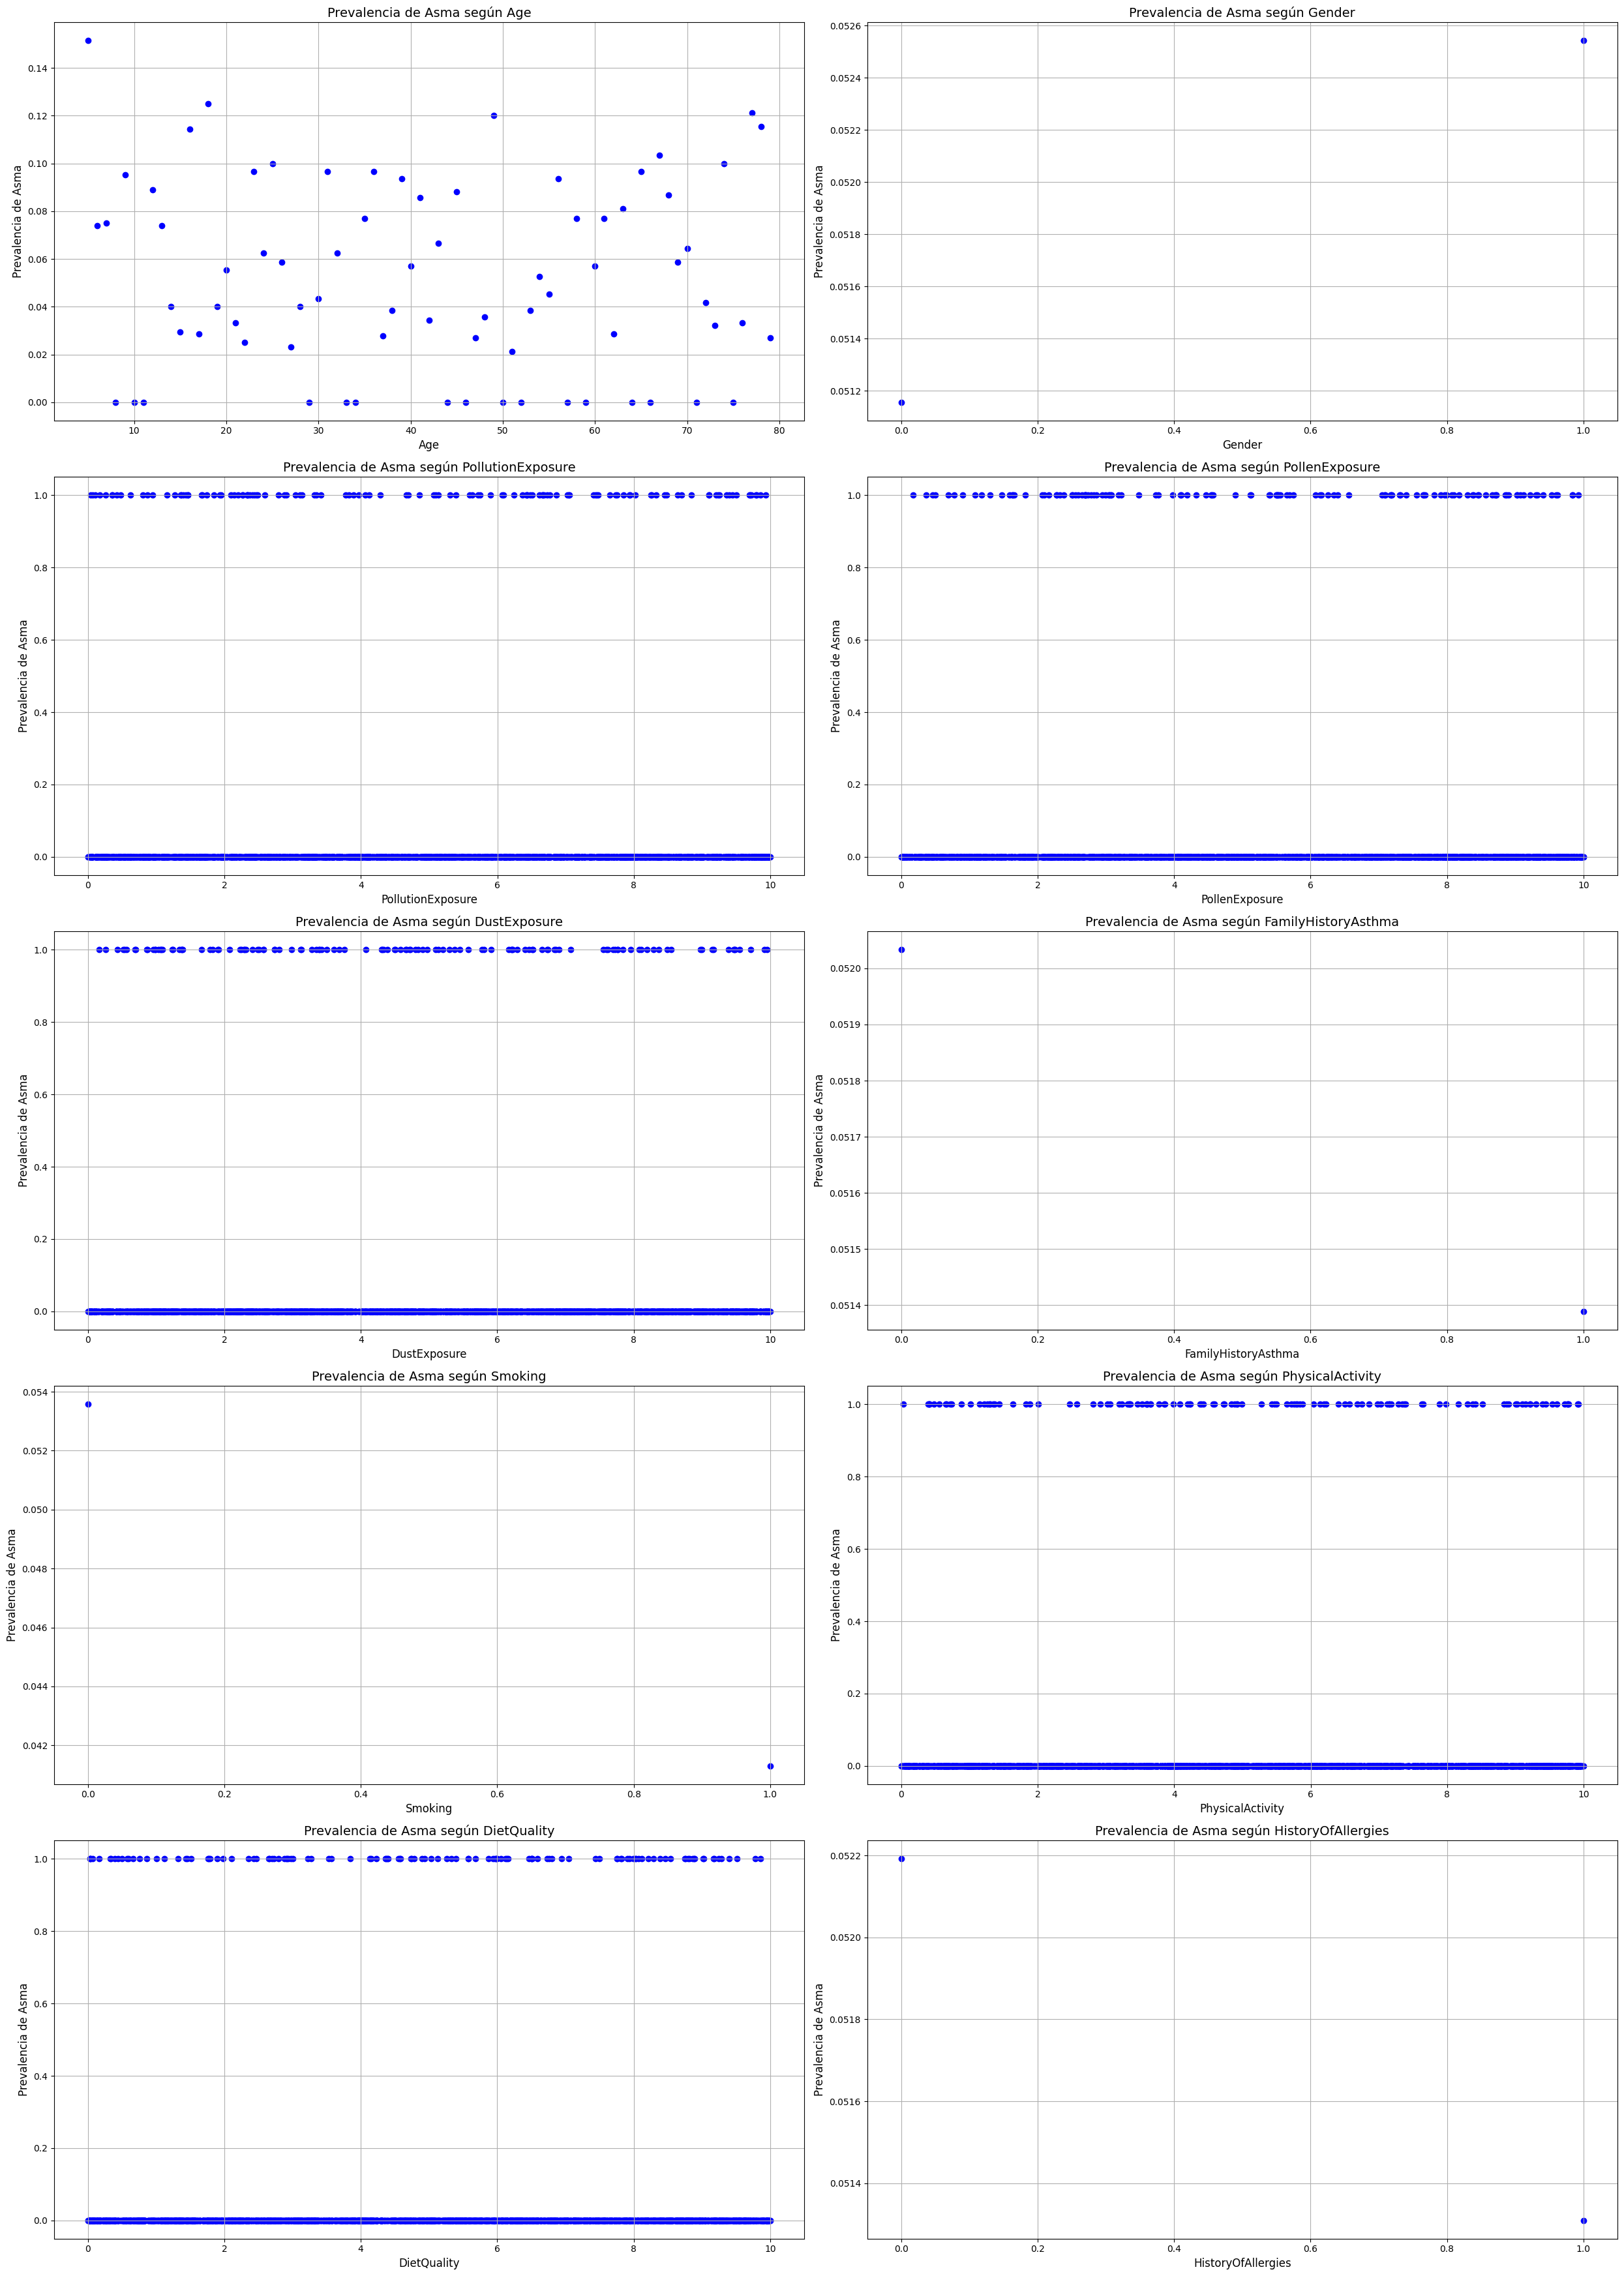

In [6]:
#Gráfica de Prevalencia del Asma (Diagnosis) vs Variables
df = df[cols].dropna()

# Variables independientes para analizar
variables = [
    "Age", "Gender", "PollutionExposure", "PollenExposure", "DustExposure",
    "FamilyHistoryAsthma", "Smoking", "PhysicalActivity",
    "DietQuality", "HistoryOfAllergies"
]

fig, axes = plt.subplots(5, 2, figsize=(25, 35))
axes = axes.flatten()

# Generación de gráficas individuales para cada relación
for i, var in enumerate(variables):
    prevalencia = df.groupby(var)['Diagnosis'].mean()
    x = prevalencia.index
    y = prevalencia.values

    axes[i].scatter(x, y, color='blue')
    axes[i].set_title(f'Prevalencia de Asma según {var}', fontsize=14)
    axes[i].set_xlabel(var, fontsize=12)
    axes[i].set_ylabel('Prevalencia de Asma', fontsize=12)
    axes[i].grid(True)

plt.tight_layout()
plt.show()

Text(0.5, 0, 'Grupo de Edad')

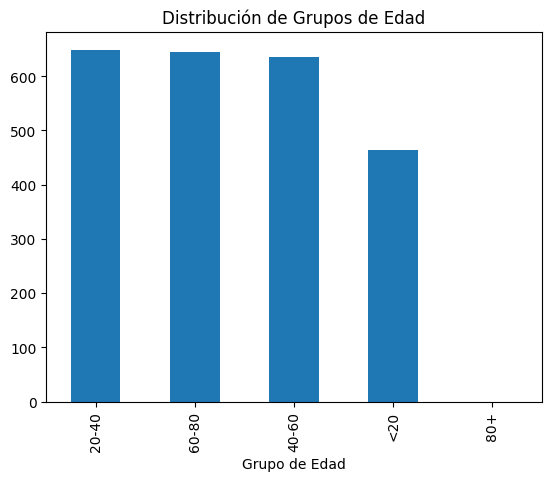

In [7]:
# Agrupación de edades en grupos
max_edad = max(80, df['Age'].max()) + 1
rangos = [0, 20, 40, 60, 80, max_edad]
labels = ['<20', '20‑40', '40‑60', '60‑80', '80+']
df['AgeGroup'] = pd.cut(df['Age'], bins=rangos, labels=labels, right=False)
df['AgeGroup'].value_counts().plot(kind='bar', title='Distribución de Grupos de Edad')
plt.xlabel('Grupo de Edad')

C:\Users\mauri\AppData\Local\Temp\ipykernel_6972\1708734768.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prevalencia = df.groupby(var)['Diagnosis'].mean()


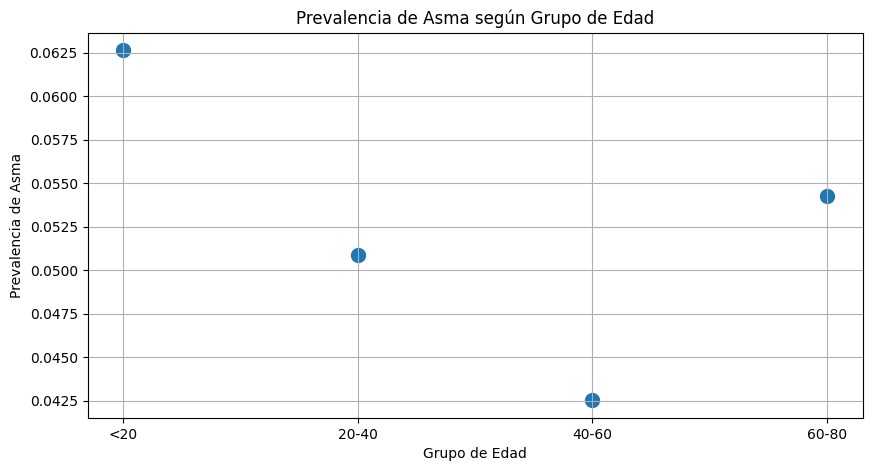

C:\Users\mauri\AppData\Local\Temp\ipykernel_6972\1708734768.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prevalencia = df.groupby(var)['Diagnosis'].mean()


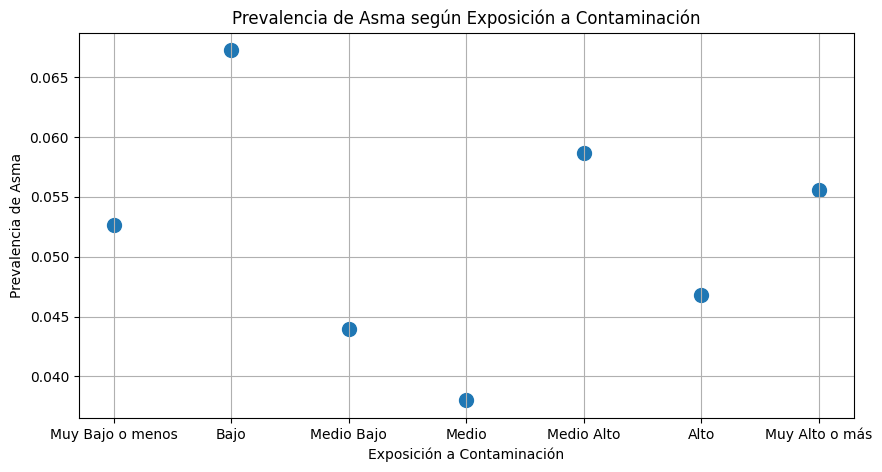

C:\Users\mauri\AppData\Local\Temp\ipykernel_6972\1708734768.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prevalencia = df.groupby(var)['Diagnosis'].mean()


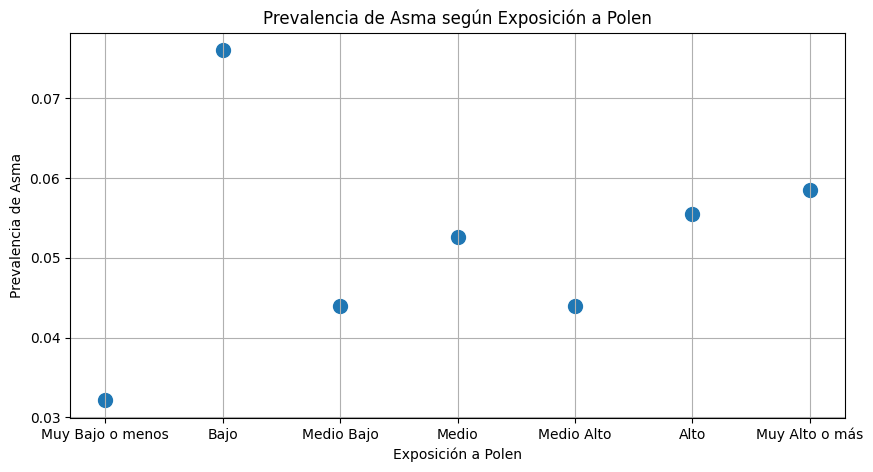

C:\Users\mauri\AppData\Local\Temp\ipykernel_6972\1708734768.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prevalencia = df.groupby(var)['Diagnosis'].mean()


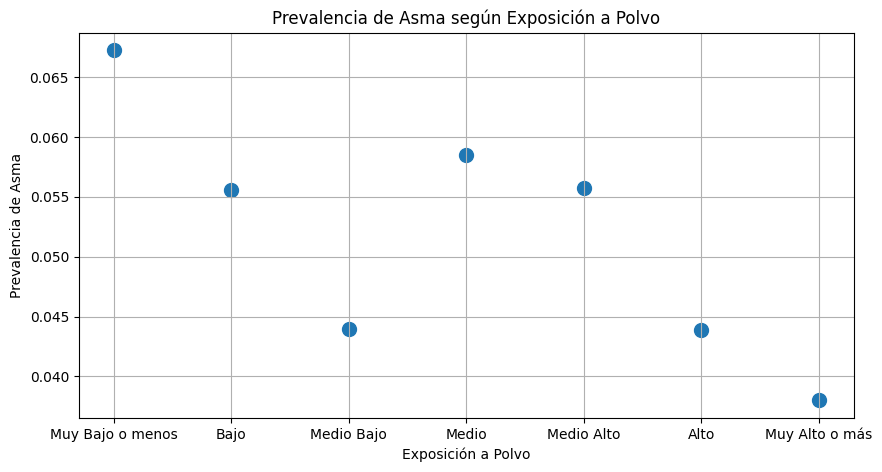

C:\Users\mauri\AppData\Local\Temp\ipykernel_6972\1708734768.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prevalencia = df.groupby(var)['Diagnosis'].mean()


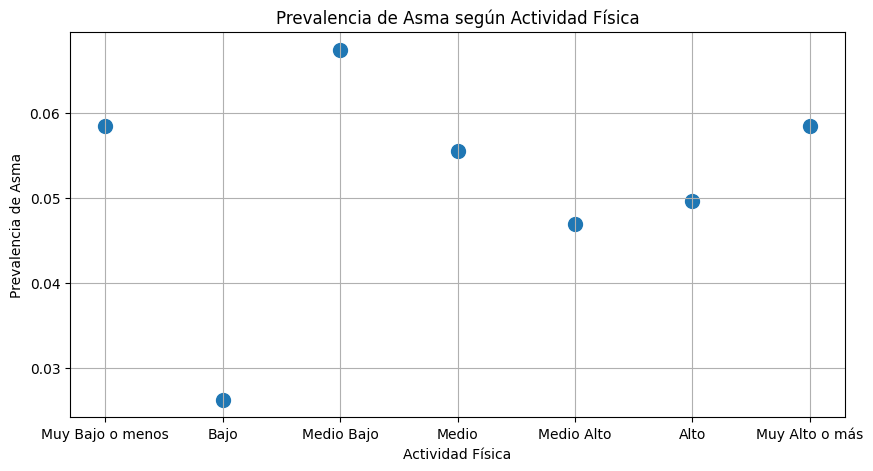

C:\Users\mauri\AppData\Local\Temp\ipykernel_6972\1708734768.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prevalencia = df.groupby(var)['Diagnosis'].mean()


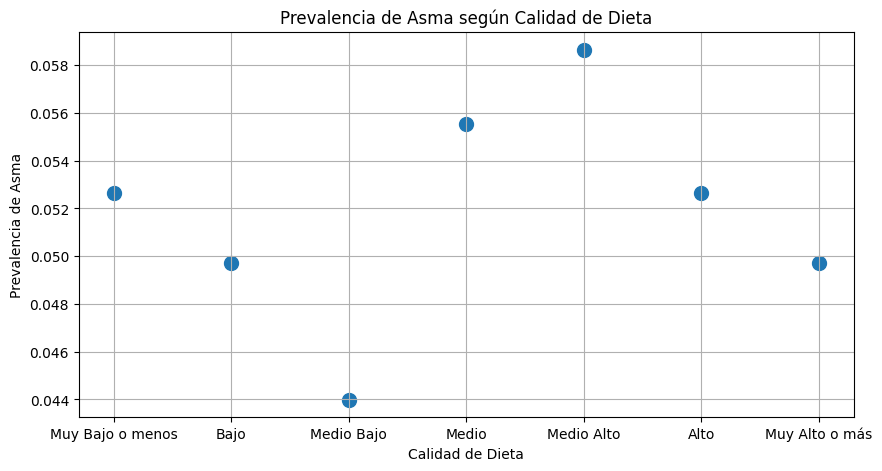

In [8]:
#Etiquetas para la distribucion en grupos en las demas variables.
etiquetas = ['Muy Bajo o menos', 'Bajo', 'Medio Bajo', 'Medio', 'Medio Alto', 'Alto', 'Muy Alto o más']

for var in ['PollutionExposure', 'PollenExposure', 'DustExposure', 'PhysicalActivity', 'DietQuality']:
    try:
        df[var + 'Group'] = pd.qcut(df[var], q=7, labels=etiquetas, duplicates='drop')
    except ValueError:
        df[var + 'Group'] = pd.cut(df[var], bins=7, labels=etiquetas, include_lowest=True)

agrupadas = {
    'AgeGroup': 'Grupo de Edad',
    'PollutionExposureGroup': 'Exposición a Contaminación',
    'PollenExposureGroup': 'Exposición a Polen',
    'DustExposureGroup': 'Exposición a Polvo',
    'PhysicalActivityGroup': 'Actividad Física',
    'DietQualityGroup': 'Calidad de Dieta'
}

#Visualización de Prevalencia de Asma vs variables en grupos (de ser necesario)
for var, titulo in agrupadas.items():
    prevalencia = df.groupby(var)['Diagnosis'].mean()
    plt.figure(figsize=(10,5))
    plt.scatter(prevalencia.index.astype(str), prevalencia.values, s=100)
    plt.title(f'Prevalencia de Asma según {titulo}')
    plt.xlabel(titulo)
    plt.ylabel('Prevalencia de Asma')
    plt.grid(True)
    plt.show()

<center><h2>Selección del método tras las la visualización de las gráficas de prevalencia vs variables independientes<h2></center>

| **Variable**                      | **Método seleccionado** | **Explicación**                                                                               |
| --------------------------------- | ----------------------- | --------------------------------------------------------------------------------------------- |
| **Edad** *(AgeGroup)*             | **Splines cúbicos**     | Relación no lineal entre grupos, con posibles picos en ciertos rangos.                        |
| **Género**                        | **Mínimos cuadrados**   | Sólo hay dos categorías, femenino o masculino.                                                |
| **Contaminación** *(agrupada)*    | **Splines cúbicos**     | La relación no es lineal ni monótona en las 7 etiquetas.                                      |
| **Exposición Pólen** *(agrupada)* | **Mínimos cuadrados**   | Las fluctuaciones son suaves, lo que permite una aproximación lineal.                         |
| **Exposición Polvo** *(agrupada)* | **Mínimos cuadrados**   | Se observa una relación visualmente lineal entre los grupos.                                  |
| **Historia Familiar**             | **Mínimos cuadrados**   | Dos categorías (sí/no), con una comparación directa.                                          |
| **Tabaquismo**                    | **Mínimos cuadrados**   | Dos categorías (sí/no), de forma lineal.                                                      |
| **Actividad Física** *(agrupada)* | **Mínimos cuadrados**   | La relación es ordenada y carece de grandes curvas, lo que permite un ajuste lineal adecuado. |
| **Calidad Dieta** *(agrupada)*    | **Splines cúbicos**     | Se presentan cambios no lineales en los grupos intermedios.                                   |
| **Historial Alergias**            | **Mínimos cuadrados**   | Dos categorías, con un ajuste directo y sencillo.                                             |


C:\Users\mauri\AppData\Local\Temp\ipykernel_6972\2724130404.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prevalencia = df.groupby('PollutionExposureGroup')['Diagnosis'].mean()


Variable: Exposición a Contaminación

Prevalencia por grupo/categoría:
Muy Bajo o menos     0.052632
Bajo                 0.067251
Medio Bajo           0.043988
Medio                0.038012
Medio Alto           0.058651
Alto                 0.046784
Muy Alto o más       0.055556

Spline cúbico global sobre los valores medios de cada grupo:
Splines cúbicos naturales:
S_0(x) = -0.004*x**3 + 0.00839785541278123*x**2 + 0.0122230020388351*x + 0.0413041841729181
S_1(x) = 0.0057*x**3 - 0.0520346275578546*x**2 + 0.138010670472786*x - 0.0459157064286723
S_2(x) = 0.0008*x**3 - 0.000783876326583047*x**2 - 0.0410106407935928*x + 0.162724518047697
S_3(x) = -0.0062*x**3 + 0.104293399983159*x**2 - 0.567066843013292*x + 1.04088500641765
S_4(x) = 0.0068*x**3 - 0.149920705468051*x**2 + 1.08970872196265*x - 2.557744128421
S_5(x) = -0.0029*x**3 + 0.081125508854242*x**2 - 0.74482507894939*x + 2.29793604662999


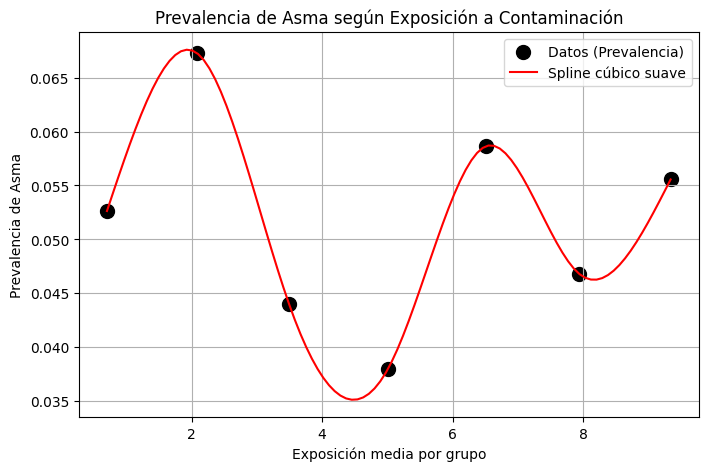

In [9]:
print('Variable: Exposición a Contaminación')
if 'PollutionExposureGroup' in df.columns:
    print('\nPrevalencia por grupo/categoría:')
    prevalencia = df.groupby('PollutionExposureGroup')['Diagnosis'].mean()
    for label, prev in prevalencia.items():
        print(f'{label:20} {prev:.6f}')
    x_medios = [df.loc[df['PollutionExposureGroup'] == label, 'PollutionExposure'].mean() for label in df['PollutionExposureGroup'].cat.categories]
    y_prevalencia = [prevalencia[label] for label in df['PollutionExposureGroup'].cat.categories]
    x_filtrado = []
    y_filtrado = []
    for x, y in zip(x_medios, y_prevalencia):
        if not (pd.isna(x) or pd.isna(y)):
            x_filtrado.append(x)
            y_filtrado.append(y)
    print('\nSpline cúbico global sobre los valores medios de cada grupo:')
    if len(x_filtrado) > 1:
        spline = spline_cubico_natural_vid(x_filtrado, y_filtrado, 4)
        if spline and 'evaluar' in spline:
            x_spline = np.linspace(min(x_filtrado), max(x_filtrado), 100)
            y_spline = spline['evaluar'](x_spline)
            import matplotlib.pyplot as plt
            plt.figure(figsize=(8,5))
            plt.scatter(x_filtrado, y_filtrado, color='black', s=100, label='Datos (Prevalencia)')
            plt.plot(x_spline, y_spline, color='red', label='Spline cúbico suave')
            plt.title('Prevalencia de Asma según Exposición a Contaminación')
            plt.xlabel('Exposición media por grupo')
            plt.ylabel('Prevalencia de Asma')
            plt.legend()
            plt.grid(True)
            plt.show()
        else:
            print('No se pudo calcular el spline.')
    else:
        print('No hay suficientes datos válidos para graficar el spline.')

Variable: Edad

Prevalencia por grupo/categoría:
<20                  0.062635
20‑40                0.050847
40‑60                0.042520
60‑80                0.054264
80+                  nan

Spline cúbico global sobre los valores medios de cada grupo:
Splines cúbicos naturales:
S_0(x) = 0.0709017278617711 - 0.0007*x
S_1(x) = 0.0713739599383667 - 0.0007*x
S_2(x) = 0.0001*x + 0.0375340157480315


C:\Users\mauri\AppData\Local\Temp\ipykernel_6972\1208062275.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prevalencia = df.groupby('AgeGroup')['Diagnosis'].mean()


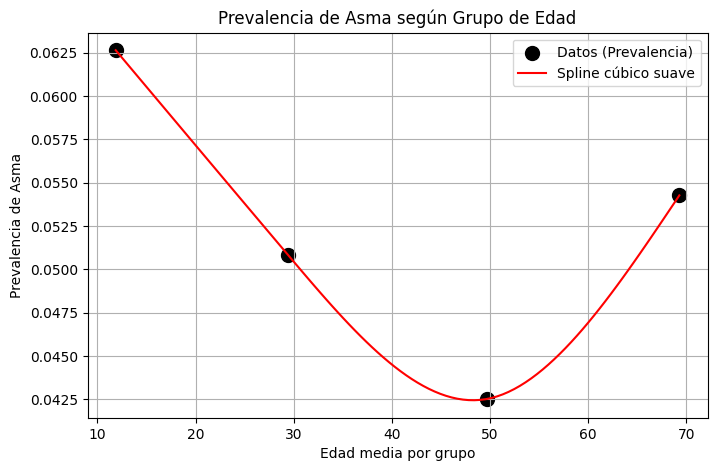

In [10]:
print('Variable: Edad')
if 'AgeGroup' in df.columns:
    print('\nPrevalencia por grupo/categoría:')
    prevalencia = df.groupby('AgeGroup')['Diagnosis'].mean()
    for label, prev in prevalencia.items():
        print(f'{label:20} {prev:.6f}')
    x_medios = [df.loc[df['AgeGroup'] == label, 'Age'].mean() for label in df['AgeGroup'].cat.categories]
    y_prevalencia = [prevalencia[label] for label in df['AgeGroup'].cat.categories]
    # Elimina nan de ambos arreglos
    x_filtrado = []
    y_filtrado = []
    for x, y in zip(x_medios, y_prevalencia):
        if not (pd.isna(x) or pd.isna(y)):
            x_filtrado.append(x)
            y_filtrado.append(y)
    print('\nSpline cúbico global sobre los valores medios de cada grupo:')
    if len(x_filtrado) > 1:
        spline = spline_cubico_natural_vid(x_filtrado, y_filtrado, 4)
        if spline and 'evaluar' in spline:
            x_spline = np.linspace(min(x_filtrado), max(x_filtrado), 100)
            y_spline = spline['evaluar'](x_spline)
            import matplotlib.pyplot as plt
            plt.figure(figsize=(8,5))
            plt.scatter(x_filtrado, y_filtrado, color='black', s=100, label='Datos (Prevalencia)')
            plt.plot(x_spline, y_spline, color='red', label='Spline cúbico suave')
            plt.title('Prevalencia de Asma según Grupo de Edad')
            plt.xlabel('Edad media por grupo')
            plt.ylabel('Prevalencia de Asma')
            plt.legend()
            plt.grid(True)
            plt.show()
        else:
            print('No se pudo calcular el spline.')
    else:
        print('No hay suficientes datos válidos para graficar el spline.')

Variable: Calidad de Dieta

Prevalencia por grupo/categoría:
Muy Bajo o menos     0.052632
Bajo                 0.049708
Medio Bajo           0.043988
Medio                0.055556
Medio Alto           0.058651
Alto                 0.052632
Muy Alto o más       0.049708

Spline cúbico global sobre los valores medios de cada grupo:
Splines cúbicos naturales:
S_0(x) = -0.0007*x**3 + 0.00144232002056813*x**2 - 0.00179061287701508*x + 0.0533762458467484
S_1(x) = 0.0022*x**3 - 0.0164244134874084*x**2 + 0.0351683876371764*x + 0.027808229339058
S_2(x) = -0.0025*x**3 + 0.0344585688375532*x**2 - 0.148813728844319*x + 0.249738916446245
S_3(x) = 0.0003*x**3 - 0.00870984411143489*x**2 + 0.0729126493838856*x - 0.129669720779684
S_4(x) = 0.0011*x**3 - 0.0242943552750721*x**2 + 0.174025969161038*x - 0.348225394036219
S_5(x) = -0.0004*x**3 + 0.0112926845756911*x**2 - 0.107370604105044*x + 0.393307297479496


C:\Users\mauri\AppData\Local\Temp\ipykernel_6972\4287609407.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prevalencia = df.groupby('DietQualityGroup')['Diagnosis'].mean()


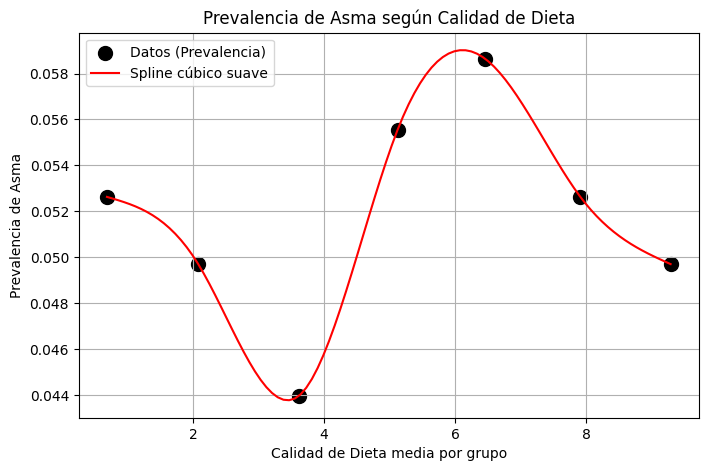

In [11]:
print('Variable: Calidad de Dieta')
if 'DietQualityGroup' in df.columns:
    print('\nPrevalencia por grupo/categoría:')
    prevalencia = df.groupby('DietQualityGroup')['Diagnosis'].mean()
    for label, prev in prevalencia.items():
        print(f'{label:20} {prev:.6f}')
    x_medios = [df.loc[df['DietQualityGroup'] == label, 'DietQuality'].mean() for label in df['DietQualityGroup'].cat.categories]
    y_prevalencia = [prevalencia[label] for label in df['DietQualityGroup'].cat.categories]
    x_filtrado = []
    y_filtrado = []
    for x, y in zip(x_medios, y_prevalencia):
        if not (pd.isna(x) or pd.isna(y)):
            x_filtrado.append(x)
            y_filtrado.append(y)
    print('\nSpline cúbico global sobre los valores medios de cada grupo:')
    if len(x_filtrado) > 1:
        spline = spline_cubico_natural_vid(x_filtrado, y_filtrado, 4)
        if spline and 'evaluar' in spline:
            x_spline = np.linspace(min(x_filtrado), max(x_filtrado), 100)
            y_spline = spline['evaluar'](x_spline)
            import matplotlib.pyplot as plt
            plt.figure(figsize=(8,5))
            plt.scatter(x_filtrado, y_filtrado, color='black', s=100, label='Datos (Prevalencia)')
            plt.plot(x_spline, y_spline, color='red', label='Spline cúbico suave')
            plt.title('Prevalencia de Asma según Calidad de Dieta')
            plt.xlabel('Calidad de Dieta media por grupo')
            plt.ylabel('Prevalencia de Asma')
            plt.legend()
            plt.grid(True)
            plt.show()
        else:
            print('No se pudo calcular el spline.')
    else:
        print('No hay suficientes datos válidos para graficar el spline.')

Variable: Género

Prevalencia por grupo/categoría:
                   0 0.051155
                   1 0.052542

Ajuste mínimos cuadrados:
0.001400, 0.051200
Ajuste: y = 0.001400 * x + 0.051200


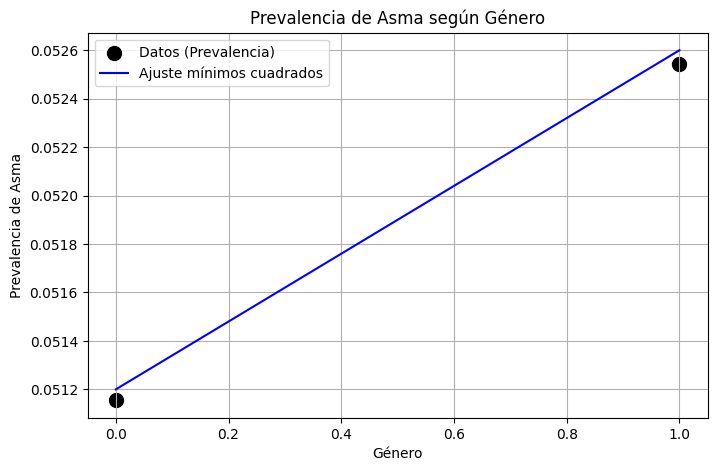

In [12]:
print('Variable: Género')
if 'Gender' in df.columns:
    print('\nPrevalencia por grupo/categoría:')
    prevalencia = df.groupby('Gender')['Diagnosis'].mean()
    for label, prev in prevalencia.items():
        print(f'{label:20} {prev:.6f}')
    x = list(prevalencia.index)
    y = list(prevalencia.values)
    print('\nAjuste mínimos cuadrados:')
    resultado = minimos_cuadrados(x, y, 4)
    print(', '.join(f'{float(r):.6f}' for r in resultado))
    # Mostrar ecuación explícita
    if len(resultado) >= 2:
        print(f'Ajuste: y = {resultado[0]:.6f} * x + {resultado[1]:.6f}')
    # Graficar ajuste
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8,5))
    plt.scatter(x, y, color='black', s=100, label='Datos (Prevalencia)')
    y_fit = [resultado[0]*xi + resultado[1] for xi in x]
    plt.plot(x, y_fit, color='blue', label='Ajuste mínimos cuadrados')
    plt.title('Prevalencia de Asma según Género')
    plt.xlabel('Género')
    plt.ylabel('Prevalencia de Asma')
    plt.legend()
    plt.grid(True)
    plt.show()

Variable: Exposición a Polen

Prevalencia por grupo/categoría:
Muy Bajo o menos     0.032164
Bajo                 0.076023
Medio Bajo           0.043988
Medio                0.052632
Medio Alto           0.043988
Alto                 0.055556
Muy Alto o más       0.058480

Ajuste mínimos cuadrados:
0.001000, 0.046900
Ajuste: y = 0.001000 * x + 0.046900


C:\Users\mauri\AppData\Local\Temp\ipykernel_6972\914173982.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prevalencia = df.groupby('PollenExposureGroup')['Diagnosis'].mean()


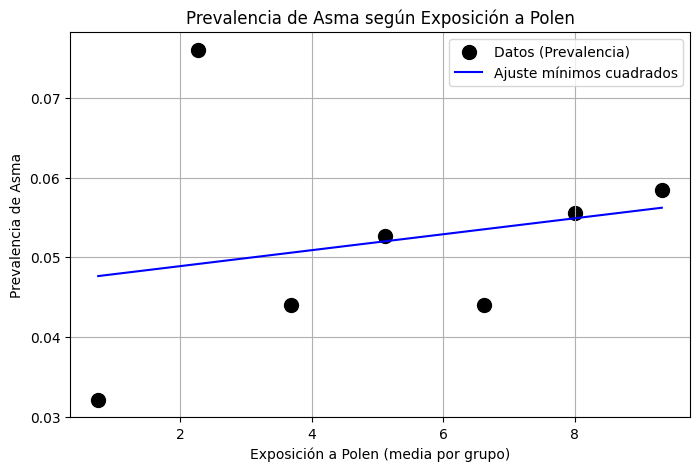

In [13]:
print('Variable: Exposición a Polen')
if 'PollenExposureGroup' in df.columns:
    print('\nPrevalencia por grupo/categoría:')
    prevalencia = df.groupby('PollenExposureGroup')['Diagnosis'].mean()
    for label, prev in prevalencia.items():
        print(f'{label:20} {prev:.6f}')
    x_medios = [df.loc[df['PollenExposureGroup'] == label, 'PollenExposure'].mean() for label in df['PollenExposureGroup'].cat.categories]
    y_prevalencia = [prevalencia[label] for label in df['PollenExposureGroup'].cat.categories]
    print('\nAjuste mínimos cuadrados:')
    resultado = minimos_cuadrados(x_medios, y_prevalencia, 4)
    print(', '.join(f'{float(r):.6f}' for r in resultado))
    if len(resultado) >= 2:
        print(f'Ajuste: y = {resultado[0]:.6f} * x + {resultado[1]:.6f}')
    # Graficar ajuste
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8,5))
    plt.scatter(x_medios, y_prevalencia, color='black', s=100, label='Datos (Prevalencia)')
    y_fit = [resultado[0]*xi + resultado[1] for xi in x_medios]
    plt.plot(x_medios, y_fit, color='blue', label='Ajuste mínimos cuadrados')
    plt.title('Prevalencia de Asma según Exposición a Polen')
    plt.xlabel('Exposición a Polen (media por grupo)')
    plt.ylabel('Prevalencia de Asma')
    plt.legend()
    plt.grid(True)
    plt.show()

Variable: Exposición a Polvo

Prevalencia por grupo/categoría:
Muy Bajo o menos     0.067251
Bajo                 0.055556
Medio Bajo           0.043988
Medio                0.058480
Medio Alto           0.055718
Alto                 0.043860
Muy Alto o más       0.038012

Ajuste mínimos cuadrados:
-0.002500, 0.064300
Ajuste: y = -0.002500 * x + 0.064300


C:\Users\mauri\AppData\Local\Temp\ipykernel_6972\2061279997.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prevalencia = df.groupby('DustExposureGroup')['Diagnosis'].mean()


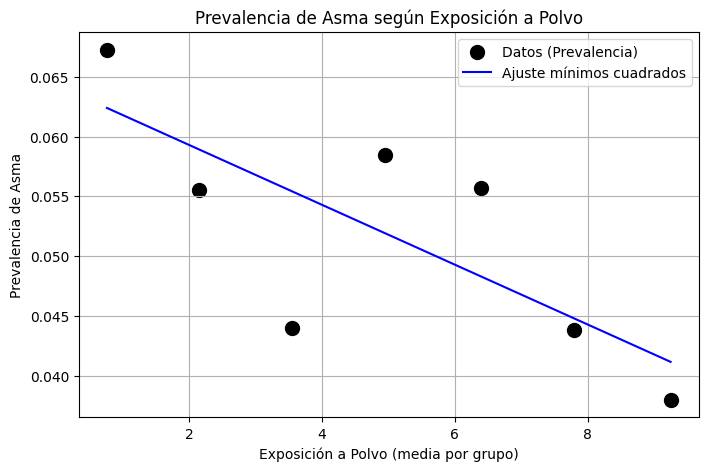

In [14]:
print('Variable: Exposición a Polvo')
if 'DustExposureGroup' in df.columns:
    print('\nPrevalencia por grupo/categoría:')
    prevalencia = df.groupby('DustExposureGroup')['Diagnosis'].mean()
    for label, prev in prevalencia.items():
        print(f'{label:20} {prev:.6f}')
    x_medios = [df.loc[df['DustExposureGroup'] == label, 'DustExposure'].mean() for label in df['DustExposureGroup'].cat.categories]
    y_prevalencia = [prevalencia[label] for label in df['DustExposureGroup'].cat.categories]
    print('\nAjuste mínimos cuadrados:')
    resultado = minimos_cuadrados(x_medios, y_prevalencia, 4)
    print(', '.join(f'{float(r):.6f}' for r in resultado))
    if len(resultado) >= 2:
        print(f'Ajuste: y = {resultado[0]:.6f} * x + {resultado[1]:.6f}')
    # Graficar ajuste
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8,5))
    plt.scatter(x_medios, y_prevalencia, color='black', s=100, label='Datos (Prevalencia)')
    y_fit = [resultado[0]*xi + resultado[1] for xi in x_medios]
    plt.plot(x_medios, y_fit, color='blue', label='Ajuste mínimos cuadrados')
    plt.title('Prevalencia de Asma según Exposición a Polvo')
    plt.xlabel('Exposición a Polvo (media por grupo)')
    plt.ylabel('Prevalencia de Asma')
    plt.legend()
    plt.grid(True)
    plt.show()

Variable: Historia Familiar

Prevalencia por grupo/categoría:
                   0 0.052033
                   1 0.051389

Ajuste mínimos cuadrados:
-0.000600, 0.052000
Ajuste: y = -0.000600 * x + 0.052000


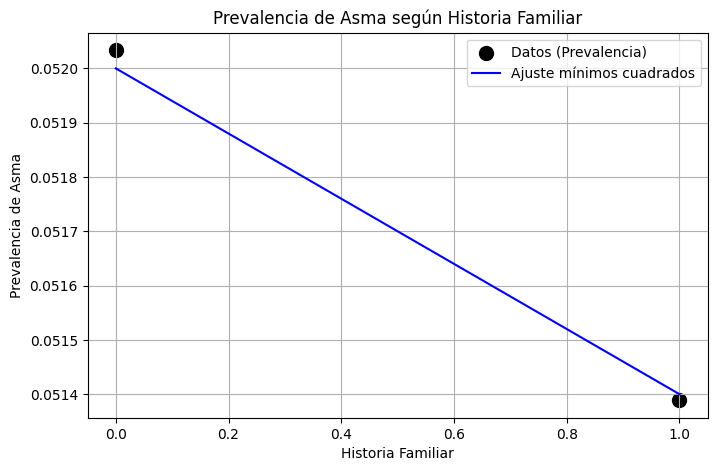

In [15]:
print('Variable: Historia Familiar')
if 'FamilyHistoryAsthma' in df.columns:
    print('\nPrevalencia por grupo/categoría:')
    prevalencia = df.groupby('FamilyHistoryAsthma')['Diagnosis'].mean()
    for label, prev in prevalencia.items():
        print(f'{label:20} {prev:.6f}')
    x = list(prevalencia.index)
    y = list(prevalencia.values)
    print('\nAjuste mínimos cuadrados:')
    resultado = minimos_cuadrados(x, y, 4)
    print(', '.join(f'{float(r):.6f}' for r in resultado))
    if len(resultado) >= 2:
        print(f'Ajuste: y = {resultado[0]:.6f} * x + {resultado[1]:.6f}')
    # Graficar ajuste
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8,5))
    plt.scatter(x, y, color='black', s=100, label='Datos (Prevalencia)')
    y_fit = [resultado[0]*xi + resultado[1] for xi in x]
    plt.plot(x, y_fit, color='blue', label='Ajuste mínimos cuadrados')
    plt.title('Prevalencia de Asma según Historia Familiar')
    plt.xlabel('Historia Familiar')
    plt.ylabel('Prevalencia de Asma')
    plt.legend()
    plt.grid(True)
    plt.show()

Variable: Tabaquismo

Prevalencia por grupo/categoría:
                   0 0.053580
                   1 0.041298

Ajuste mínimos cuadrados:
-0.012300, 0.053600
Ajuste: y = -0.012300 * x + 0.053600


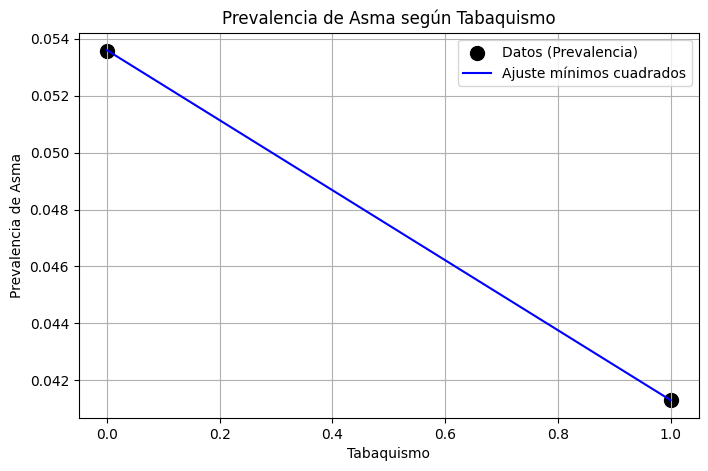

In [16]:
print('Variable: Tabaquismo')
if 'Smoking' in df.columns:
    print('\nPrevalencia por grupo/categoría:')
    prevalencia = df.groupby('Smoking')['Diagnosis'].mean()
    for label, prev in prevalencia.items():
        print(f'{label:20} {prev:.6f}')
    x = list(prevalencia.index)
    y = list(prevalencia.values)
    print('\nAjuste mínimos cuadrados:')
    resultado = minimos_cuadrados(x, y, 4)
    print(', '.join(f'{float(r):.6f}' for r in resultado))
    if len(resultado) >= 2:
        print(f'Ajuste: y = {resultado[0]:.6f} * x + {resultado[1]:.6f}')
    # Graficar ajuste
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8,5))
    plt.scatter(x, y, color='black', s=100, label='Datos (Prevalencia)')
    y_fit = [resultado[0]*xi + resultado[1] for xi in x]
    plt.plot(x, y_fit, color='blue', label='Ajuste mínimos cuadrados')
    plt.title('Prevalencia de Asma según Tabaquismo')
    plt.xlabel('Tabaquismo')
    plt.ylabel('Prevalencia de Asma')
    plt.legend()
    plt.grid(True)
    plt.show()

Variable: Actividad Física

Prevalencia por grupo/categoría:
Muy Bajo o menos     0.058480
Bajo                 0.026316
Medio Bajo           0.067449
Medio                0.055556
Medio Alto           0.046921
Alto                 0.049708
Muy Alto o más       0.058480

Ajuste mínimos cuadrados:
0.000700, 0.048500
Ajuste: y = 0.000700 * x + 0.048500


C:\Users\mauri\AppData\Local\Temp\ipykernel_6972\1129743774.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prevalencia = df.groupby('PhysicalActivityGroup')['Diagnosis'].mean()


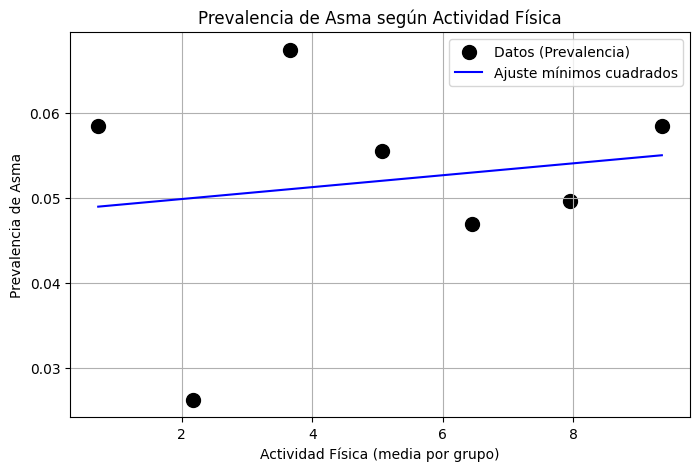

In [17]:
print('Variable: Actividad Física')
if 'PhysicalActivityGroup' in df.columns:
    print('\nPrevalencia por grupo/categoría:')
    prevalencia = df.groupby('PhysicalActivityGroup')['Diagnosis'].mean()
    for label, prev in prevalencia.items():
        print(f'{label:20} {prev:.6f}')
    x_medios = [df.loc[df['PhysicalActivityGroup'] == label, 'PhysicalActivity'].mean() for label in df['PhysicalActivityGroup'].cat.categories]
    y_prevalencia = [prevalencia[label] for label in df['PhysicalActivityGroup'].cat.categories]
    print('\nAjuste mínimos cuadrados:')
    resultado = minimos_cuadrados(x_medios, y_prevalencia, 4)
    print(', '.join(f'{float(r):.6f}' for r in resultado))
    if len(resultado) >= 2:
        print(f'Ajuste: y = {resultado[0]:.6f} * x + {resultado[1]:.6f}')
    # Graficar ajuste
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8,5))
    plt.scatter(x_medios, y_prevalencia, color='black', s=100, label='Datos (Prevalencia)')
    y_fit = [resultado[0]*xi + resultado[1] for xi in x_medios]
    plt.plot(x_medios, y_fit, color='blue', label='Ajuste mínimos cuadrados')
    plt.title('Prevalencia de Asma según Actividad Física')
    plt.xlabel('Actividad Física (media por grupo)')
    plt.ylabel('Prevalencia de Asma')
    plt.legend()
    plt.grid(True)
    plt.show()

Variable: Historia de Alergias

Prevalencia por grupo/categoría:
                   0 0.052192
                   1 0.051309

Ajuste mínimos cuadrados:
-0.000900, 0.052200
Ajuste: y = -0.000900 * x + 0.052200


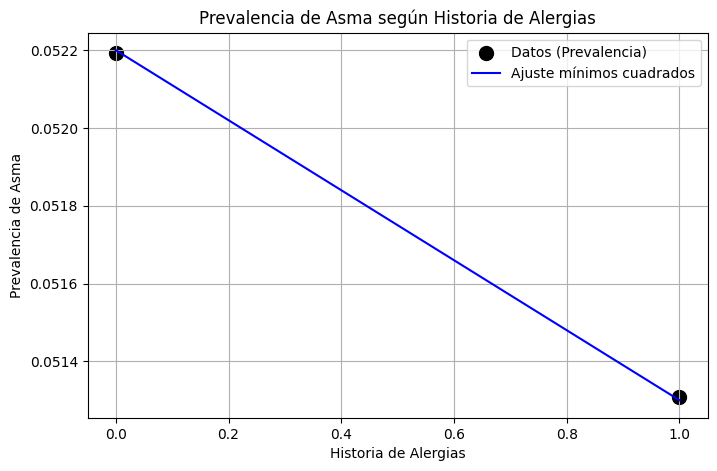

In [18]:
print('Variable: Historia de Alergias')
if 'HistoryOfAllergies' in df.columns:
    print('\nPrevalencia por grupo/categoría:')
    prevalencia = df.groupby('HistoryOfAllergies')['Diagnosis'].mean()
    for label, prev in prevalencia.items():
        print(f'{label:20} {prev:.6f}')
    x = list(prevalencia.index)
    y = list(prevalencia.values)
    print('\nAjuste mínimos cuadrados:')
    resultado = minimos_cuadrados(x, y, 4)
    print(', '.join(f'{float(r):.6f}' for r in resultado))
    if len(resultado) >= 2:
        print(f'Ajuste: y = {resultado[0]:.6f} * x + {resultado[1]:.6f}')
    # Graficar ajuste
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8,5))
    plt.scatter(x, y, color='black', s=100, label='Datos (Prevalencia)')
    y_fit = [resultado[0]*xi + resultado[1] for xi in x]
    plt.plot(x, y_fit, color='blue', label='Ajuste mínimos cuadrados')
    plt.title('Prevalencia de Asma según Historia de Alergias')
    plt.xlabel('Historia de Alergias')
    plt.ylabel('Prevalencia de Asma')
    plt.legend()
    plt.grid(True)
    plt.show()